In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from math import factorial

In [2]:
A = 4  # traffic intensity (from Exercise 4)
m = 10  # max lines

def g(i):
    """Unnormalized target: A^i / i!"""
    if i < 0 or i > m:
        return 0.0
    return (A ** i) / factorial(i)

In [3]:
def metropolis_hastings(n_samples, burn_in=1000):
    samples = []
    x = 0  # start state
    
    for t in range(n_samples + burn_in):
        # Propose: go left or right with equal probability
        y = x + np.random.choice([-1, 1])
        
        # Acceptance probability (g handles out-of-bounds by returning 0)
        if g(x) == 0:
            alpha = 1.0
        else:
            alpha = min(1.0, g(y) / g(x))
        
        # Accept or reject
        if np.random.uniform() < alpha:
            x = y
        
        # Only collect after burn-in
        if t >= burn_in:
            samples.append(x)
    
    return np.array(samples)

samples = metropolis_hastings(n_samples=50000, burn_in=1000)
print("First 20 samples:", samples[:20])
print("Unique states visited:", np.unique(samples))

First 20 samples: [5 5 6 5 5 4 3 4 5 4 5 6 5 5 4 3 2 3 3 4]
Unique states visited: [ 0  1  2  3  4  5  6  7  8  9 10]


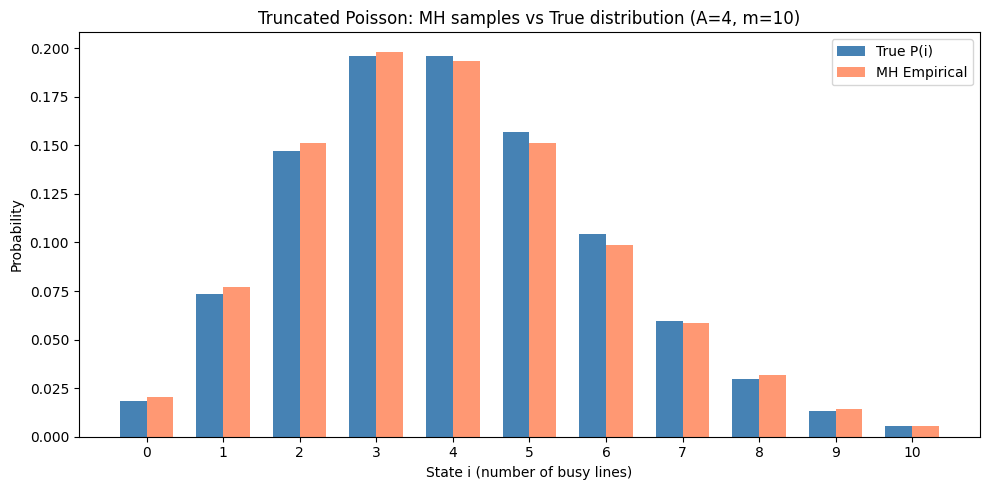

True probs:      [0.0184 0.0735 0.1469 0.1959 0.1959 0.1567 0.1045 0.0597 0.0299 0.0133
 0.0053]
Empirical probs: [0.0202 0.0771 0.151  0.1982 0.1933 0.1509 0.0987 0.0583 0.0319 0.0144
 0.0058]


In [4]:
# Compute true (normalized) distribution analytically
true_probs = np.array([g(i) for i in range(m+1)])
true_probs = true_probs / true_probs.sum()  # normalize by computing c

# Empirical frequencies from MH samples
counts = np.array([(samples == i).sum() for i in range(m+1)])
empirical_probs = counts / counts.sum()

# Plot
x_vals = np.arange(m+1)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_vals - width/2, true_probs, width, label='True P(i)', color='steelblue')
ax.bar(x_vals + width/2, empirical_probs, width, label='MH Empirical', color='coral', alpha=0.8)

ax.set_xlabel('State i (number of busy lines)')
ax.set_ylabel('Probability')
ax.set_title(f'Truncated Poisson: MH samples vs True distribution (A={A}, m={m})')
ax.legend()
ax.set_xticks(x_vals)
plt.tight_layout()
plt.show()

print("True probs:     ", np.round(true_probs, 4))
print("Empirical probs:", np.round(empirical_probs, 4))

In [5]:
n = len(samples)
expected_counts = true_probs * n
observed_counts = counts.astype(float)

# Chi-squared statistic
chi2_stat = np.sum((observed_counts - expected_counts)**2 / expected_counts)

# Degrees of freedom: number of states - 1
# (we don't estimate any parameters from data, so no extra reduction)
df = m  # 11 states - 1 = 10

# p-value: probability of seeing this statistic or larger under H0
p_value = 1 - chi2.cdf(chi2_stat, df)

print(f"Chi-squared statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom:    {df}")
print(f"p-value:               {p_value:.4f}")
print()
if p_value > 0.05:
    print("✓ Fail to reject H0: samples are consistent with the true distribution")
else:
    print("✗ Reject H0: samples do NOT match the true distribution")

Chi-squared statistic: 69.4750
Degrees of freedom:    10
p-value:               0.0000

✗ Reject H0: samples do NOT match the true distribution


In [6]:
def metropolis_hastings_thinned(n_samples, burn_in=5000, thinning=10):
    samples = []
    x = 0
    total_iters = burn_in + n_samples * thinning
    t_after_burnin = 0

    for t in range(total_iters):
        y = x + np.random.choice([-1, 1])
        if g(x) == 0:
            alpha = 1.0
        else:
            alpha = min(1.0, g(y) / g(x))
        if np.random.uniform() < alpha:
            x = y
        if t >= burn_in:
            t_after_burnin += 1
            if t_after_burnin % thinning == 0:
                samples.append(x)

    return np.array(samples)

samples_thin = metropolis_hastings_thinned(n_samples=50000, burn_in=5000, thinning=10)

# Rerun chi2 test
n2 = len(samples_thin)
counts2 = np.array([(samples_thin == i).sum() for i in range(m+1)])
expected2 = true_probs * n2
chi2_stat2 = np.sum((counts2 - expected2)**2 / expected2)
p_value2 = 1 - chi2.cdf(chi2_stat2, df)

print(f"Thinned samples:       {n2}")
print(f"Chi-squared statistic: {chi2_stat2:.4f}")
print(f"Degrees of freedom:    {df}")
print(f"p-value:               {p_value2:.4f}")
if p_value2 > 0.05:
    print("✓ Fail to reject H0: samples consistent with true distribution")
else:
    print("✗ Reject H0")

Thinned samples:       50000
Chi-squared statistic: 9.3406
Degrees of freedom:    10
p-value:               0.5001
✓ Fail to reject H0: samples consistent with true distribution


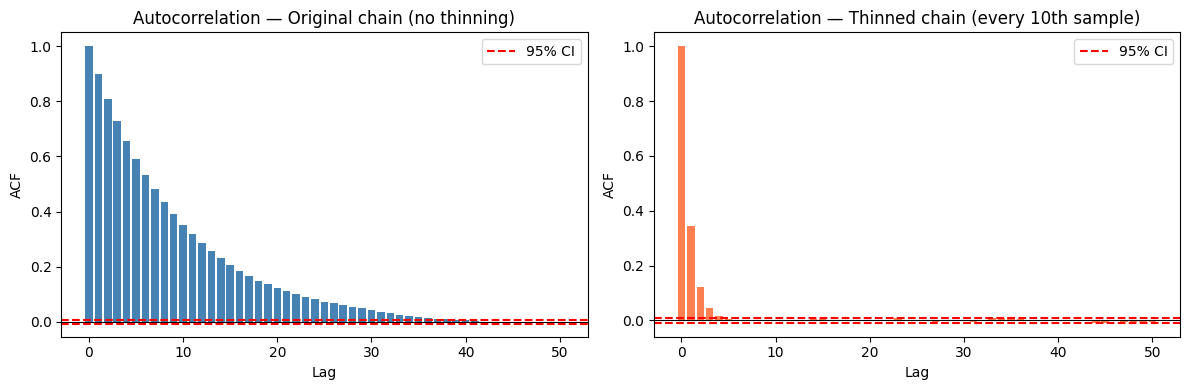

In [7]:
def autocorrelation(samples, max_lag=50):
    n = len(samples)
    mean = np.mean(samples)
    var = np.var(samples)
    acf = []
    for lag in range(max_lag + 1):
        cov = np.mean((samples[:n-lag] - mean) * (samples[lag:] - mean))
        acf.append(cov / var)
    return np.array(acf)

acf_original = autocorrelation(samples)        # original chain
acf_thinned  = autocorrelation(samples_thin)   # thinned chain

lags = np.arange(51)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(lags, acf_original, color='steelblue')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(1.96/np.sqrt(len(samples)), color='red', linestyle='--', label='95% CI')
axes[0].axhline(-1.96/np.sqrt(len(samples)), color='red', linestyle='--')
axes[0].set_title('Autocorrelation — Original chain (no thinning)')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('ACF')
axes[0].legend()

axes[1].bar(lags, acf_thinned, color='coral')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(1.96/np.sqrt(len(samples_thin)), color='red', linestyle='--', label='95% CI')
axes[1].axhline(-1.96/np.sqrt(len(samples_thin)), color='red', linestyle='--')
axes[1].set_title('Autocorrelation — Thinned chain (every 10th sample)')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('ACF')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
A1, A2 = 4, 4
m2 = 10

def g2(i, j):
    """Unnormalized joint distribution"""
    if i < 0 or j < 0 or i + j > m2:
        return 0.0
    return (A1**i / factorial(i)) * (A2**j / factorial(j))

# Compute true joint distribution (normalize over all valid states)
states = [(i, j) for i in range(m2+1) for j in range(m2+1) if i+j <= m2]
g2_vals = np.array([g2(i, j) for i, j in states])
Z = g2_vals.sum()  # normalizing constant
true_joint = {(i,j): g2(i,j)/Z for i,j in states}

print(f"Number of valid states: {len(states)}")
print(f"Normalizing constant Z: {Z:.4f}")
print(f"Sample true probs — P(0,0)={true_joint[(0,0)]:.4f}, P(4,4)={true_joint[(4,4)]:.4f}")

Number of valid states: 66
Normalizing constant Z: 2432.1213
Sample true probs — P(0,0)=0.0004, P(4,4)=0.0468


In [9]:
def mh_2d(n_samples, burn_in=5000, thinning=10):
    samples = []
    i, j = 0, 0  # start state
    moves = [(-1,0), (1,0), (0,-1), (0,1)]  # 4 possible proposals
    total_iters = burn_in + n_samples * thinning
    t_after_burnin = 0

    for t in range(total_iters):
        # Propose a neighbor
        di, dj = moves[np.random.randint(4)]
        i_new, j_new = i + di, j + dj

        # Acceptance
        g_curr = g2(i, j)
        g_prop = g2(i_new, j_new)

        if g_curr == 0:
            alpha = 1.0
        else:
            alpha = min(1.0, g_prop / g_curr)

        if np.random.uniform() < alpha:
            i, j = i_new, j_new

        if t >= burn_in:
            t_after_burnin += 1
            if t_after_burnin % thinning == 0:
                samples.append((i, j))

    return samples

samples_2d = mh_2d(n_samples=50000, burn_in=5000, thinning=10)
print(f"Total samples: {len(samples_2d)}")
print(f"First 5 samples: {samples_2d[:5]}")

# Empirical distribution
from collections import Counter
counts_2d = Counter(samples_2d)
n_2d = len(samples_2d)

# Chi-squared test
chi2_stat_2d = sum(
    (counts_2d.get(s, 0) - true_joint[s] * n_2d)**2 / (true_joint[s] * n_2d)
    for s in states
)
df_2d = len(states) - 1  # 65
p_value_2d = 1 - chi2.cdf(chi2_stat_2d, df_2d)

print(f"\nChi-squared statistic: {chi2_stat_2d:.4f}")
print(f"Degrees of freedom:    {df_2d}")
print(f"p-value:               {p_value_2d:.4f}")
if p_value_2d > 0.05:
    print("✓ Fail to reject H0")
else:
    print("✗ Reject H0")

Total samples: 50000
First 5 samples: [(2, 4), (3, 4), (3, 3), (3, 4), (1, 5)]

Chi-squared statistic: 75.4819
Degrees of freedom:    65
p-value:               0.1757
✓ Fail to reject H0


In [10]:
def mh_2d_coordinatewise(n_samples, burn_in=5000, thinning=10):
    samples = []
    i, j = 0, 0
    total_iters = burn_in + n_samples * thinning
    t_after_burnin = 0

    for t in range(total_iters):
        # Alternate: even steps update i, odd steps update j
        if t % 2 == 0:
            # Propose new i, keep j fixed
            i_new = i + np.random.choice([-1, 1])
            g_curr = g2(i, j)
            g_prop = g2(i_new, j)
            alpha = min(1.0, g_prop / g_curr) if g_curr > 0 else 1.0
            if np.random.uniform() < alpha:
                i = i_new
        else:
            # Propose new j, keep i fixed
            j_new = j + np.random.choice([-1, 1])
            g_curr = g2(i, j)
            g_prop = g2(i, j_new)
            alpha = min(1.0, g_prop / g_curr) if g_curr > 0 else 1.0
            if np.random.uniform() < alpha:
                j = j_new

        if t >= burn_in:
            t_after_burnin += 1
            if t_after_burnin % thinning == 0:
                samples.append((i, j))

    return samples

samples_coord = mh_2d_coordinatewise(n_samples=50000, burn_in=5000, thinning=10)
print(f"Total samples: {len(samples_coord)}")

# Chi-squared test
counts_coord = Counter(samples_coord)
n_coord = len(samples_coord)

chi2_stat_coord = sum(
    (counts_coord.get(s, 0) - true_joint[s] * n_coord)**2 / (true_joint[s] * n_coord)
    for s in states
)
p_value_coord = 1 - chi2.cdf(chi2_stat_coord, df_2d)

print(f"Chi-squared statistic: {chi2_stat_coord:.4f}")
print(f"Degrees of freedom:    {df_2d}")
print(f"p-value:               {p_value_coord:.4f}")
if p_value_coord > 0.05:
    print("✓ Fail to reject H0")
else:
    print("✗ Reject H0")

Total samples: 50000
Chi-squared statistic: 86.5847
Degrees of freedom:    65
p-value:               0.0381
✗ Reject H0


In [11]:
# Try thinning = 50 instead of 10
samples_coord2 = mh_2d_coordinatewise(n_samples=50000, burn_in=5000, thinning=50)

counts_coord2 = Counter(samples_coord2)
n_coord2 = len(samples_coord2)

chi2_stat_coord2 = sum(
    (counts_coord2.get(s, 0) - true_joint[s] * n_coord2)**2 / (true_joint[s] * n_coord2)
    for s in states
)
p_value_coord2 = 1 - chi2.cdf(chi2_stat_coord2, df_2d)

print(f"Thinning=50")
print(f"Chi-squared statistic: {chi2_stat_coord2:.4f}")
print(f"Degrees of freedom:    {df_2d}")
print(f"p-value:               {p_value_coord2:.4f}")
if p_value_coord2 > 0.05:
    print("✓ Fail to reject H0")
else:
    print("✗ Reject H0")

Thinning=50
Chi-squared statistic: 67.6522
Degrees of freedom:    65
p-value:               0.3867
✓ Fail to reject H0


In [12]:
def sample_truncated_poisson(A, max_val):
    """Sample from truncated Poisson on {0,1,...,max_val} with parameter A"""
    probs = np.array([(A**k) / factorial(k) for k in range(max_val + 1)])
    probs = probs / probs.sum()
    return np.random.choice(max_val + 1, p=probs)

def gibbs_2d(n_samples, burn_in=5000, thinning=10):
    samples = []
    i, j = 0, 0
    total_iters = burn_in + n_samples * thinning
    t_after_burnin = 0

    for t in range(total_iters):
        # Sample i from P(i | j) = TruncPoisson(A1, max=m-j)
        i = sample_truncated_poisson(A1, m2 - j)
        # Sample j from P(j | i) = TruncPoisson(A2, max=m-i)
        j = sample_truncated_poisson(A2, m2 - i)

        if t >= burn_in:
            t_after_burnin += 1
            if t_after_burnin % thinning == 0:
                samples.append((i, j))

    return samples

samples_gibbs = gibbs_2d(n_samples=50000, burn_in=5000, thinning=10)
print(f"Total samples: {len(samples_gibbs)}")

# Chi-squared test
counts_gibbs = Counter(samples_gibbs)
n_gibbs = len(samples_gibbs)

chi2_stat_gibbs = sum(
    (counts_gibbs.get(s, 0) - true_joint[s] * n_gibbs)**2 / (true_joint[s] * n_gibbs)
    for s in states
)
p_value_gibbs = 1 - chi2.cdf(chi2_stat_gibbs, df_2d)

print(f"Chi-squared statistic: {chi2_stat_gibbs:.4f}")
print(f"Degrees of freedom:    {df_2d}")
print(f"p-value:               {p_value_gibbs:.4f}")
if p_value_gibbs > 0.05:
    print("✓ Fail to reject H0")
else:
    print("✗ Reject H0")

Total samples: 50000
Chi-squared statistic: 62.8533
Degrees of freedom:    65
p-value:               0.5524
✓ Fail to reject H0


Method                        Chi2    df    p-value   Thinning
(a) Direct 2D MH           75.4819    65     0.1757         10
(b) Coordinatewise MH      67.6522    65     0.3867         50
(c) Gibbs sampling         62.8533    65     0.5524         10


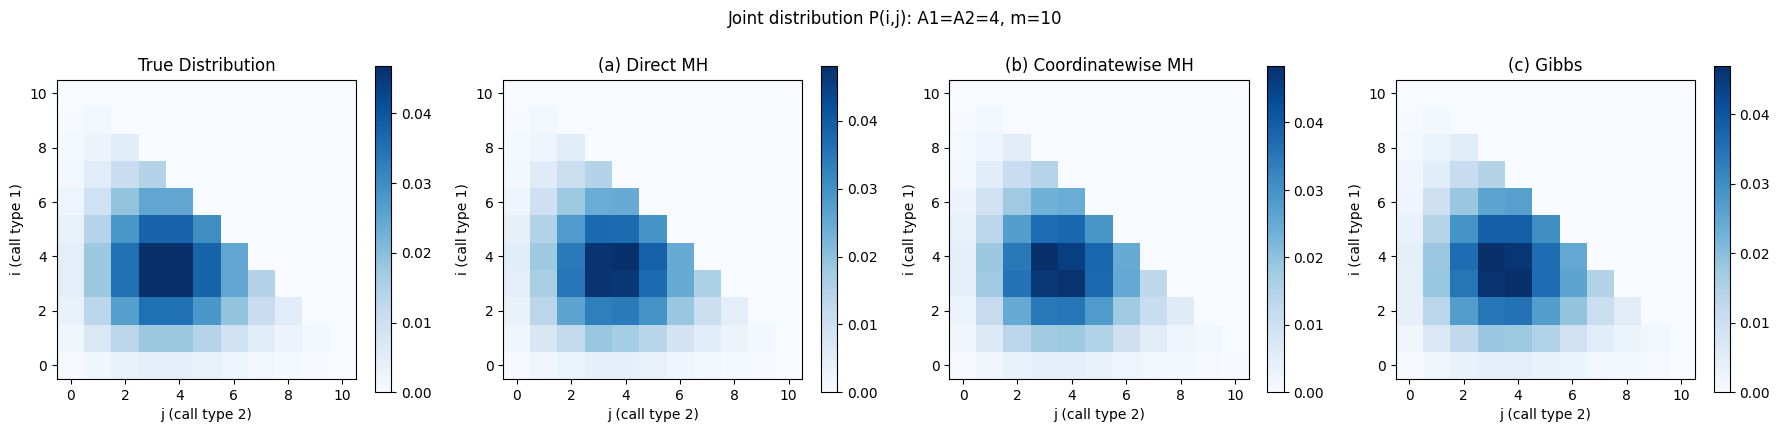

In [13]:
# Summary table
print("=" * 60)
print(f"{'Method':<25} {'Chi2':>8} {'df':>5} {'p-value':>10} {'Thinning':>10}")
print("=" * 60)
print(f"{'(a) Direct 2D MH':<25} {chi2_stat_2d:>8.4f} {df_2d:>5} {p_value_2d:>10.4f} {10:>10}")
print(f"{'(b) Coordinatewise MH':<25} {chi2_stat_coord2:>8.4f} {df_2d:>5} {p_value_coord2:>10.4f} {50:>10}")
print(f"{'(c) Gibbs sampling':<25} {chi2_stat_gibbs:>8.4f} {df_2d:>5} {p_value_gibbs:>10.4f} {10:>10}")
print("=" * 60)

# Heatmaps: true vs each method
def to_matrix(dist, n):
    """Convert counter/dict to (m+1) x (m+1) matrix of probabilities"""
    mat = np.zeros((m2+1, m2+1))
    for (i,j), v in dist.items():
        mat[i, j] = v / n if isinstance(v, (int, float)) and n > 1 else v
    return mat

true_mat    = to_matrix(true_joint, 1)
mh_mat      = to_matrix(counts_2d, n_2d)
coord_mat   = to_matrix(counts_coord2, n_coord2)
gibbs_mat   = to_matrix(counts_gibbs, n_gibbs)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
titles = ['True Distribution', '(a) Direct MH', '(b) Coordinatewise MH', '(c) Gibbs']
mats   = [true_mat, mh_mat, coord_mat, gibbs_mat]

for ax, mat, title in zip(axes, mats, titles):
    im = ax.imshow(mat, origin='lower', cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('j (call type 2)')
    ax.set_ylabel('i (call type 1)')
    plt.colorbar(im, ax=ax)

plt.suptitle(f'Joint distribution P(i,j): A1=A2={A1}, m={m2}', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
rho = 0.5

# Sample (xi, gamma) from bivariate normal
mean = [0, 0]
cov  = [[1, rho], [rho, 1]]

np.random.seed(42)
xi, gamma = np.random.multivariate_normal(mean, cov)

# Transform to (theta, psi)
theta_true = np.exp(xi)
psi_true   = np.exp(gamma)

print(f"Sampled (xi, gamma) = ({xi:.4f}, {gamma:.4f})")
print(f"Transformed (theta, psi) = ({theta_true:.4f}, {psi_true:.4f})")
print(f"theta = prior mean, psi = prior variance")

Sampled (xi, gamma) = (-0.3610, -0.4993)
Transformed (theta, psi) = (0.6970, 0.6070)
theta = prior mean, psi = prior variance
